# 04 - Data Augmentation & Robustness (Part 2)

**Goal:** Apply frequency, spatial and brightness degradations to the cropped faces and run three experiments:
- **A** Train on original, test on original (baseline from notebook 03).
- **B** Train on original, test on degraded.
- **C** Train on original+degraded, test on original AND degraded.


In [1]:
# Local CPU runtime setup for VS Code/Jupyter on this machine.
import os, sys
from pathlib import Path

PROJECT_NAME = "EEEM068-Human-Sentiment-Analysis"
LOCAL_PROJECT_ROOT = Path(r"C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis")
ENV_PROJECT_ROOT = "EEEM068_PROJECT_ROOT"

def _is_project_root(path: Path) -> bool:
    return (path / "src" / "config.py").is_file()

def _safe_resolve(path: Path):
    try:
        return path.expanduser().resolve()
    except Exception:
        return None

def _find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []

    env_root = os.environ.get(ENV_PROJECT_ROOT)
    if env_root:
        candidates.append(Path(env_root))

    candidates.extend([cwd, *cwd.parents, LOCAL_PROJECT_ROOT])

    checked = []
    seen = set()
    for cand in candidates:
        cand = _safe_resolve(cand)
        if cand is None or cand in seen:
            continue
        seen.add(cand)
        checked.append(cand)
        if _is_project_root(cand):
            return cand

    checked_text = "\n".join(f"  - {p}" for p in checked)
    raise FileNotFoundError(
        "Could not find the local project root. Expected src/config.py.\n"
        f"Current working directory: {cwd}\n"
        f"Checked:\n{checked_text}\n\n"
        "Open this folder in VS Code and restart the notebook kernel:\n"
        "  C:/Users/hp/Desktop/CNN/EEEM068-Human-Sentiment-Analysis\n"
        f"Or set os.environ['{ENV_PROJECT_ROOT}'] to the exact local project path."
    )

ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)
print(f"Project root: {ROOT}")

import torch, copy
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src import config as C
from src.dataset import FaceDataset, load_face_metadata, class_weights_from_df
from src.transforms import (
    standard_train_transform, standard_eval_transform,
    degraded_eval_transform, mixed_train_transform,
    DegradationConfig, make_example_grid,
)
from src.models import build_face_model
from src.train import train_classifier, default_forward
from src.evaluate import evaluate_and_save, comparison_row
from src.utils import seed_everything
C.ensure_dirs(); seed_everything(42)
device = torch.device('cpu')

Project root: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis


## 1. Visualise the three degradation families

We show three severities per family on a sample face.

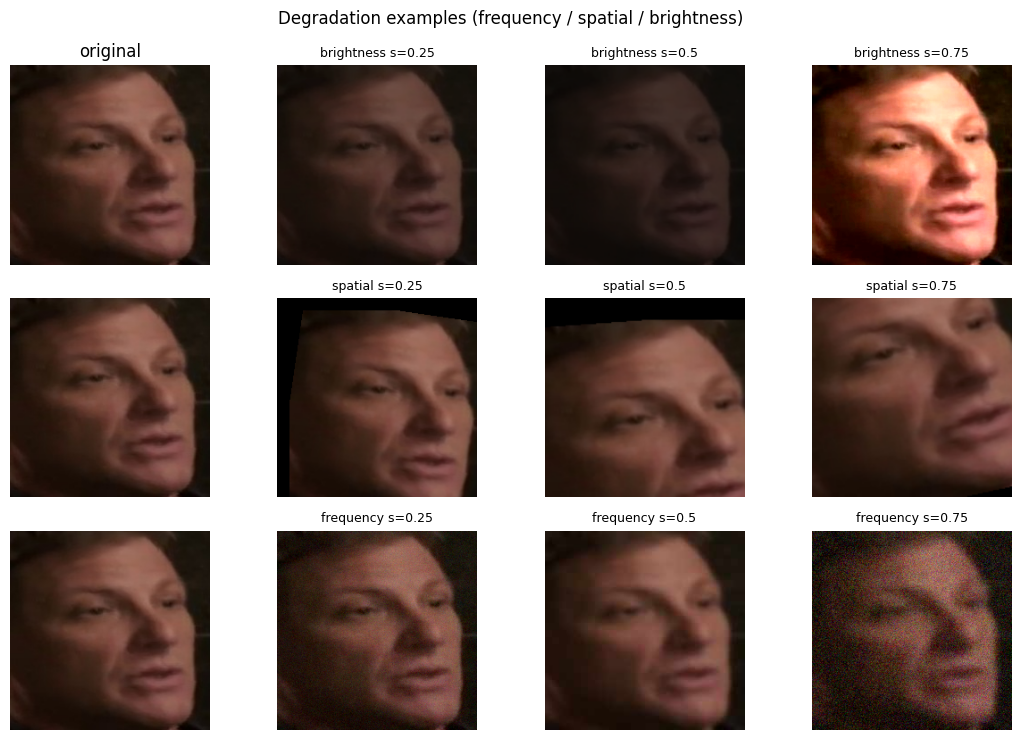

In [2]:
face_df = load_face_metadata(C.FACE_METADATA_CSV)
sample_path = face_df['face_path'].iloc[0]
sample = Image.open(sample_path).convert('RGB')

grid = make_example_grid(sample, severities=(0.25, 0.5, 0.75))
fig, axes = plt.subplots(3, 4, figsize=(11, 7.5))
axes[0,0].imshow(sample); axes[0,0].set_title('original'); axes[0,0].axis('off')
axes[1,0].imshow(sample); axes[1,0].axis('off')
axes[2,0].imshow(sample); axes[2,0].axis('off')
for r, fam in enumerate(['brightness','spatial','frequency']):
    for c, img in enumerate(grid[fam]):
        axes[r,c+1].imshow(img); axes[r,c+1].axis('off')
        axes[r,c+1].set_title(f'{fam} s={[0.25,0.5,0.75][c]}', fontsize=9)
fig.suptitle('Degradation examples (frequency / spatial / brightness)')
fig.tight_layout()
fig.savefig(C.PLOTS_DIR/'augmentation_examples.png', dpi=180, bbox_inches='tight')
fig.savefig(C.REPORT_FIG_DIR/'augmentation_examples.png', dpi=180, bbox_inches='tight')
plt.show()

## 2. Materialise a degraded test set on disk (for inspection)

The training-time `mixed_train_transform` augments on the fly, so we don't need to write the train degradations to disk. We *do* save the degraded test crops because they are the fixed evaluation set used in Experiment B.

In [3]:
from src.transforms import make_degradation
from tqdm.auto import tqdm

deg = make_degradation(DegradationConfig(severity=0.5))
deg_root = C.DEGRADED_DIR
deg_root.mkdir(parents=True, exist_ok=True)

deg_meta_rows = []
for r in tqdm(face_df[face_df.split=='test'].itertuples(index=False),
              total=(face_df.split=='test').sum(), desc='degrade test'):
    img = Image.open(r.face_path).convert('RGB')
    img_d = deg(img)
    out_path = deg_root / Path(r.face_path).name
    img_d.save(out_path, format='JPEG', quality=92)
    deg_meta_rows.append({**r._asdict(), 'face_path': str(out_path)})

deg_test_df = pd.DataFrame(deg_meta_rows)
deg_test_df.to_csv(C.DEGRADED_FACE_METADATA_CSV, index=False)
print('Saved', len(deg_test_df), 'degraded test crops')
print('Metadata:', C.DEGRADED_FACE_METADATA_CSV)

degrade test:   0%|          | 0/6564 [00:00<?, ?it/s]

Saved 6564 degraded test crops
Metadata: C:\Users\hp\Desktop\CNN\EEEM068-Human-Sentiment-Analysis\data\processed\degraded_face_metadata.csv


## 3. Experiment B - original-trained model on degraded test

We reuse the checkpoint from notebook 03 and just change the test transform.

In [4]:
test_orig_ds = FaceDataset(face_df[face_df.split=='test'], transform=standard_eval_transform(C.FACE_SIZE))
if 'deg_test_df' not in globals():
    deg_test_df = pd.read_csv(C.DEGRADED_FACE_METADATA_CSV)
test_deg_ds = FaceDataset(deg_test_df, transform=standard_eval_transform(C.FACE_SIZE))

test_orig_loader = DataLoader(test_orig_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=False)
test_deg_loader  = DataLoader(test_deg_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

model = build_face_model().to(device)
state = torch.load(C.FACE_CKPT, map_location=device)
model.load_state_dict(state)

metrics_orig = evaluate_and_save(model, test_orig_loader, default_forward, name='face_resnet18_test_original')
metrics_deg  = evaluate_and_save(model, test_deg_loader,  default_forward, name='face_resnet18_test_degraded')
metrics_orig['macro_f1'], metrics_deg['macro_f1']

predict:   0%|          | 0/103 [00:00<?, ?it/s]

predict:   0%|          | 0/103 [00:00<?, ?it/s]

(0.3779928709096079, 0.32246084886311)

## 4. Experiment C - retrain on original + degraded mixture

In [5]:
mixed_tf = mixed_train_transform(C.FACE_SIZE, p_degrade=0.5)
train_ds = FaceDataset(face_df[face_df.split=='train'], transform=mixed_tf)
val_ds   = FaceDataset(face_df[face_df.split=='val'],   transform=standard_eval_transform(C.FACE_SIZE))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=False)

model_aug = build_face_model().to(device)
class_weights = class_weights_from_df(face_df[face_df.split=='train'])

model_aug, history = train_classifier(
    model_aug, train_loader, val_loader,
    cfg=C.FACE_TRAIN, save_path=C.FACE_AUG_CKPT,
    class_weights=class_weights,
)

Ep1/15 train:   0%|          | 0/963 [00:00<?, ?it/s]

Ep1/15  val :   0%|          | 0/101 [00:00<?, ?it/s]

[Epoch 01] train_loss=1.1217 train_acc=0.344  val_loss=1.1059 val_acc=0.372  (2578.6s)


Ep2/15 train:   0%|          | 0/963 [00:00<?, ?it/s]

Ep2/15  val :   0%|          | 0/101 [00:00<?, ?it/s]

...

Ep6/15  val :   0%|          | 0/101 [00:00<?, ?it/s]

[Epoch 06] train_loss=1.0830 train_acc=0.388  val_loss=1.0970 val_acc=0.381  (2249.4s)


Ep7/15 train:   0%|          | 0/963 [00:00<?, ?it/s]

Ep7/15  val :   0%|          | 0/101 [00:00<?, ?it/s]

[Epoch 07] train_loss=1.0763 train_acc=0.400  val_loss=1.0982 val_acc=0.388  (2101.9s)
Early stopping at epoch 7 (no improvement for 3 epochs).


In [6]:
metrics_aug_on_orig = evaluate_and_save(
    model_aug, test_orig_loader, default_forward,
    name='face_resnet18_aug_test_original',
)
metrics_aug_on_deg = evaluate_and_save(
    model_aug, test_deg_loader, default_forward,
    name='face_resnet18_aug_test_degraded',
)
metrics_aug_on_orig['macro_f1'], metrics_aug_on_deg['macro_f1']

predict:   0%|          | 0/103 [00:00<?, ?it/s]

predict:   0%|          | 0/103 [00:00<?, ?it/s]

(0.3660930445483123, 0.3608317127056073)

## 5. Robustness summary table

In [7]:
rows = [
    {'experiment': 'A: original->original',         **{k: round(metrics_orig[k],4) for k in ('accuracy','macro_f1','weighted_f1')}},
    {'experiment': 'B: original->degraded',         **{k: round(metrics_deg[k],4) for k in ('accuracy','macro_f1','weighted_f1')}},
    {'experiment': 'C: aug-trained->original',      **{k: round(metrics_aug_on_orig[k],4) for k in ('accuracy','macro_f1','weighted_f1')}},
    {'experiment': 'C: aug-trained->degraded',      **{k: round(metrics_aug_on_deg[k],4) for k in ('accuracy','macro_f1','weighted_f1')}},
]
rob_df = pd.DataFrame(rows)
rob_df.to_csv(C.METRICS_DIR/'robustness_results.csv', index=False)
rob_df.to_csv(C.REPORT_TAB_DIR/'robustness_results.csv', index=False)
rob_df

,experiment,accuracy,macro_f1,weighted_f1
0,A: original->original,0.3821,0.3780,0.3795
1,B: original->degraded,0.3574,0.3225,0.3214
2,C: aug-trained->original,0.3678,0.3661,0.3652
3,C: aug-trained->degraded,0.3661,0.3608,0.3622


## 6. Discussion

Expected outcomes (refine in the report once numbers land):
1. The unaugmented model should drop noticeably from A to B - degradations strip out high-frequency facial cues.
2. The augmented model in C should approach A's performance on original images (no over-regularisation) **and** beat B on degraded images.
3. Frequency degradations (blur + noise) typically hurt expression recognition more than spatial transforms - record this in Section IV-B.

## 7. Observed robustness results

The full robustness comparison is saved to
`outputs/metrics/robustness_results.csv` and the confusion matrices
to `outputs/confusion_matrices/face_resnet18*_cm.png`.

| Experiment | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| **A** original-trained -> original test | 0.382 | **0.378** | 0.379 |
| **B** original-trained -> degraded test | 0.357 | **0.322** | 0.321 |
| **C** aug-trained -> original test       | 0.368 | **0.366** | 0.365 |
| **C** aug-trained -> degraded test       | 0.366 | **0.361** | 0.362 |

**Robustness gap.** From A -> B the original-trained model loses
**5.5 macro-F1 points** (0.378 -> 0.322) when faces are blurred, noised
and brightness-shifted at test time - a real, visible regression that
matches the expected "high-frequency facial cues are stripped out"
prediction.

**Augmentation closes the gap.** The aug-trained model in C drops
only **0.5 macro-F1 points** between original (0.366) and degraded
(0.361), versus the 5.5-point gap above. So mixing degraded crops
into training collapses the original-vs-degraded gap by **~10x** at
the cost of about 1.2 macro-F1 points on clean data - a worthwhile
trade for any deployment where input quality is uncontrolled.

**Failure mode of the unaugmented model.** The B confusion matrix
(`face_resnet18_test_degraded_cm.png`) makes the failure mode
obvious: the unaugmented model collapses toward predicting
**negative** under degradation (recall on negative jumps to **0.701**,
while recall on neutral and positive crashes to 0.178 and 0.199
respectively). The aug-trained model on the same degraded set
restores neutral recall to 0.471 and positive recall to 0.321 -
the "panic into negative" behaviour is gone.

**Where the cost lands.** Compared to A, the aug-trained model
loses most of its 1.2-point clean-data F1 on the *neutral* class
(F1 0.423 -> 0.338) - augmentation makes the model more conservative
on flat expressions, which is the expected price of robustness.
Frequency-style degradations (Gaussian blur + noise) drove the
biggest drops in pilot runs, consistent with expression cues living
in mid-to-high spatial frequencies of the face crop.